In [1]:
import numpy as np
import pandas as pd
import os
import multiprocessing
#import stuff and define functions
from typing import Dict, List, Optional, Union
from pathlib import Path
from sklearn.decomposition import IncrementalPCA, PCA
from CustomFunctions import shapePCAtools, file_management, shparam_mod
import math
from vtk.util import numpy_support
import vtk
from aicsshparam import shtools
import pickle as pk


In [2]:
#directories for opening and saving pca stuff
basedir = 'E:/Aaron/Combined_37C_Confocal_PCA_s5_LLS_Apply/'
savedir = basedir + 'Data_and_Figs/'
if not os.path.exists(savedir):
    os.makedirs(savedir)

In [3]:
############# gather data from all experiments ###############
# get the datasets to be combined
datasets = [x for x in os.listdir(savedir) if 'Shape_Metrics' in x]
exlists = [x for x in os.listdir(savedir) if 'ListToExclude' in x]

#### open shape metrics and exclude bad SH cells
smlst = []
for d in range(len(datasets)):
    #open shape metrics
    sm = pd.read_csv(savedir + datasets[d], index_col = 0)
    #open the list of cells to exclude
    excludes = pd.read_csv(savedir + exlists[d], index_col=0)
    sm = sm.loc[~sm.cell.isin(excludes.cell)]
    smlst.append(sm)
smdf = pd.concat(smlst)
    
    
#open all of the other metrics from the single csv files
if __name__ == '__main__':
    pool = multiprocessing.Pool(processes=60)
    csvlist = [basedir + 'processed_data/' + i +'_cell_info.csv' for i in smdf.cell.to_list()]
    celllist = pool.map(file_management.multicsv, csvlist)
    pool.close()
    pool.join()
cellinfo = pd.concat(celllist)


### make dataframes and merge    
all_llsdf = smdf.merge(cellinfo.drop(columns=['image', 'cropx (pixels)',
       'cropy (pixels)', 'cropz (pixels)']), left_on = 'cell', right_on = 'cell')

In [4]:
########### FILTER THE DATA A BIT ###############
print(len(all_llsdf))

############# filter out shape outliers #############
llsdf = all_llsdf[all_llsdf.Cell_Volume > 458]
llsdf = llsdf[llsdf.Cell_SurfaceArea < 1700]
print(len(llsdf))

############## filter out speed outliers #############
### these seem to come from segmentation failures that move the cell centroid
llsdf = llsdf[(llsdf.speed < 1.3) | (llsdf.speed.isna())]
print(len(llsdf))

############# filter out 20240528 ##############
llsdf = llsdf[~llsdf.cell.str.contains('20240528', na=False)]
print(len(llsdf))

########### filter out all but the cells that I followed for 1hr #########
longcells = [i for i, x in llsdf.groupby('CellID') if len(x)>360]
llsdf = llsdf[llsdf.CellID.isin(longcells)]
#also filter out the one cell I followed that got stuck
llsdf = llsdf[llsdf.CellID != '20240527_488_EGFP-CAAX_640_SPY650-DNA_cell3_01']
print(len(llsdf))

########### filter out cells that touch ############
llsdf = llsdf.sort_values(['CellID','time']).reset_index(drop=True)
touch_ind = llsdf.groupby('CellID').apply(lambda x:
                              x[(abs(x.Cell_Volume.pct_change())>0.25)&(abs(x.Cell_SurfaceArea.pct_change())>0.25)]).index
actual_ind = [x[1] for x in touch_ind]
#drop the whole range because this only happens for a brief window with one cell
llsdf = llsdf.drop(index=range(actual_ind[0],actual_ind[-1]))
print(len(llsdf))

#### make sure to reset the index after dropping all of the stuff
llsdf = llsdf.reset_index(drop=True)

14552
14492
14475
14475
8452
8442


In [5]:
# ############# optionally scale volumes to match confocal data
# # open confocal pca model
# confocaldir = "E:/Aaron/Combined_37C_Confocal_PCA_smooth/Data_and_Figs/"
# pca = pk.load(open(confocaldir+"pca.pkl",'rb')) 
# #open confocal cell stats
# condf = pd.read_csv(confocaldir+'Shape_Metrics_with_PCs.csv', index_col=0)

# ##### scale LLS volumes to confocal volumes
# #get volume ratio
# vrat = condf.Cell_Volume.mean()/llsdf.Cell_Volume.mean()

# #actually rescale and get new coeffs
# meshlist = ['E:/Aaron/random_lls_smooth/Meshes/'+x+'_cell_mesh.vtp' for x in llsdf.cell.to_list()]
# if __name__ == "__main__":
#     with multiprocessing.Pool(processes=60) as pool:
#         results = []
#         for m in meshlist:
#             result = pool.apply_async(shparam_mod.read_mesh_rescale_shcoeffs, args=(
#                                         m,
#                                         vrat,
#                                         vrat,
#                                         lmax,
#                                         ))
#             results.append(result)
#         results = [r.get() for r in results]
# newcoeffs = pd.DataFrame(results)

# #remove old coeffs
# llsdf = llsdf.drop(columns=[x for x in llsdf.columns.to_list() if 'shcoeffs' in x])
# #replace with new coeffs
# llsdf = llsdf.merge(newcoeffs, left_on='cell', right_on='cell')

In [5]:
######### Perform PCA and divide cells into shape space bins ################

#specify number of PCs and number of bins
npcs = 8
nbins = 5
bins = list(range(1,nbins+1))
lmax = 10

# open confocal pca model
confocaldir = "E:/Aaron/Combined_37C_Confocal_PCA_s5/Data_and_Figs/"
pca = pk.load(open(confocaldir+"pca.pkl",'rb')) 


# tranform the LLS data
lls_coeff = llsdf[[x for x in llsdf.columns.to_list() if 'shcoeffs' in x]]
lls_transform = pca.transform(lls_coeff)

# Dataframe of transformed variable
pc_names = [f"Cell_PC{c}" for c in range(1, 1 + npcs)]
df_trans = pd.DataFrame(data=lls_transform, columns=pc_names, index = lls_coeff.index)




# ########## flip PC1 so that the flux is clockwise
# flipind = 0
# df_trans[pc_names[flipind]] *= -1
# pca.components_[flipind] *= -1


# ##### digitize shape mode and also filter extremes
# df_dig = pd.DataFrame(index = df_trans.index)
# for count, col in enumerate(df_trans.columns.to_list()):
#     df_digit, bin_indexes, (bin_centers, pc_std) = shapePCAtools.digitize_shape_mode(
#         df = df_trans,
#         feature = col,
#         nbins = nbins,
#         filter_based_on = df_trans.columns.to_list(),
#         filter_extremes_pct = float(1),
#         save = None,
#         return_freqs_per_structs = False
#     )
#     #put bin_indexes into a larger list that I can later iterate through
#     df_dig = df_dig.merge(df_digit[[col,'bin']], left_index = True, right_index = True)
#     df_dig = df_dig.rename(columns={'bin':f'PC{count+1}_bins'})


######### add PCs to big data frame
llsdf = llsdf.merge(df_trans[pc_names], left_index = True, right_index = True)
        

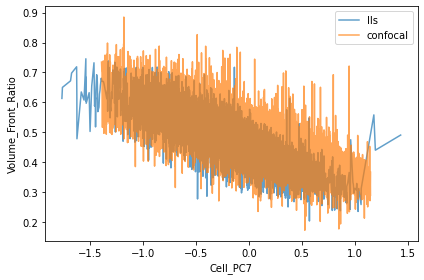

In [7]:
############### CHECK THAT PCs ARE GOING IN THE SAME DIRECTION FOR BOTH DATASETS ###########
import matplotlib.pyplot as plt
import seaborn as sns


condf = pd.read_csv(confocaldir + 'All_Data_with_CGPS_bins.csv', index_col = 0)


fig, axes = plt.subplots(1, 1)

sns.lineplot(x = 'Cell_PC7', y = 'Volume_Front_Ratio', data = llsdf, alpha = 0.7, label = 'lls')
#     ax.hist(orig_trans[pc_names].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'original')
sns.lineplot(x = 'PC7', y = 'Volume_Front_Ratio', data = condf, alpha = 0.7, label = 'confocal')

plt.tight_layout()

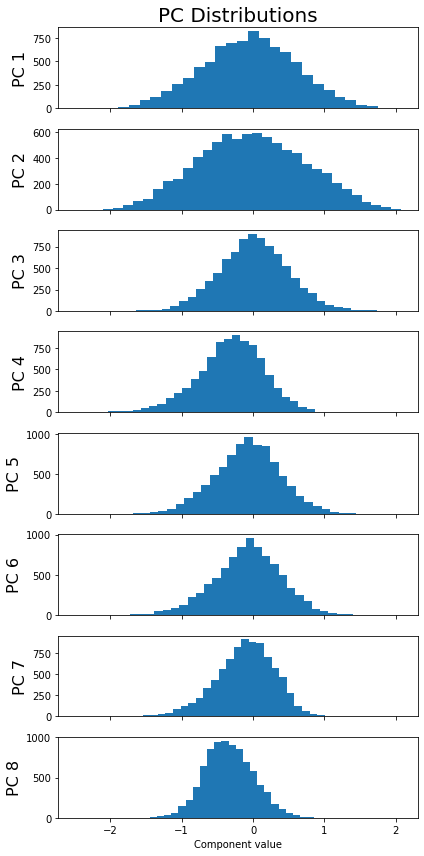

In [8]:
##################### PCA relevant figures #######################


########### plot distributions of PCs ###################
import matplotlib.pyplot as plt
fig, axes = plt.subplots(npcs, 1, figsize=(6,12), sharex=True)
for i, ax in enumerate(axes[:]):
    ax.hist(llsdf[pc_names].iloc[:,i].values, 30)
# for i, ax in enumerate(axes[:,1]):
#     ax.hist(nuc_weights[:,i], 30, (-2,2))
    
axes[0].set_title("PC Distributions", fontsize = 20)
# axes[0,1].set_title("Nucleus Distributions", fontsize = 20)
[ax.set_ylabel("PC %i"%(i+1), fontsize = 16) for i, ax in enumerate(axes[:])];
axes[7].set_xlabel("Component value")

plt.tight_layout()
plt.savefig(savedir+ 'PC distributions.png', bbox_inches='tight')


# condf = pd.read_csv(confocaldir + 'All_Data_with_CGPS_bins.csv', index_col = 0)


# #pre-volume adjusted PCs
# origdf = smdf.merge(atidf.drop(columns=['image', 'cropx (pixels)',
#        'cropy (pixels)', 'cropz (pixels)']), left_on = 'cell', right_on = 'cell')
# origdf = origdf[origdf.Cell_Volume > 458]
# origdf = origdf[origdf.Cell_SurfaceArea < 1700]
# origdf = origdf[origdf.speed < 1.3]
# origdf = origdf[~origdf.cell.str.contains('20240528', na=False)].reset_index(drop=True)
# longcells = [i for i, x in origdf.groupby('CellID') if len(x)>360]
# origdf = origdf[origdf.CellID.isin(longcells)]
# # tranform the LLS data
# orig_coeff = origdf[[x for x in origdf.columns.to_list() if 'shcoeffs' in x]]
# orig_transform = pca.transform(orig_coeff)
# # Dataframe of transformed variable
# pc_names = [f"Cell_PC{c}" for c in range(1, 1 + npcs)]
# orig_trans = pd.DataFrame(data=orig_transform, columns=pc_names, index = orig_coeff.index)
# # orig_trans['Cell_Volume'] = origdf.Cell_Volume
# # for pcid, pc_name in enumerate(pc_names):
# #     pearson = np.corrcoef(orig_trans.Cell_Volume.values, orig_trans[pc_name].values)
# #     if pearson[0, 1] < 0:
# #         orig_trans[pc_name] *= -1
# #         pca.components_[pcid] *= -1
# # orig_trans = orig_trans.drop(columns = 'Cell_Volume')


# ########## plot distributions of PCs ###################
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(10, 1, figsize=(6,12), sharex=True)
# for i, ax in enumerate(axes[:]):
#     ax.hist(df_trans[pc_names].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'lls')
# #     ax.hist(orig_trans[pc_names].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'original')
#     ax.hist(condf[[x.split('Cell_')[-1] for x in pc_names]].iloc[:,i].values, 30, density = True,alpha = 0.7, label = 'confocal')
# axes[0].set_title("PC Distributions", fontsize = 20)
# # axes[0,1].set_title("Nucleus Distributions", fontsize = 20)
# [ax.set_ylabel("PC %i"%(i+1), fontsize = 16) for i, ax in enumerate(axes[:])];
# axes[-1].set_xlabel("Component value")
# ax.legend()
# plt.tight_layout()
# plt.savefig(savedir+ 'PC distributions.png', bbox_inches='tight')



In [36]:
############# BIN PCs TO USE IN CGPS ###################

#remove the "Cell_" from PCs
for x in llsdf.columns.to_list():
    if 'PC' in x:
        llsdf = llsdf.rename(columns = {x:x.replace('Cell_','')})

        
#### use the confocal bin size
bin_centers = pd.read_csv(confocaldir + 'PC_bin_centers.csv', index_col = 0)
nbins = len(bin_centers.iloc[:,0])
#check if lls data needs more bins
binmultis = []
for p in ['PC1','PC7']:
    #get bin centers
    binc = bin_centers[p].values
    #get bin width
    binw = np.diff(binc)[0]/2
    #get bin edges
    bine = np.unique([np.round(binc+bw, 6) for bw in [binw,-binw]])
    #get edge differences
    mindiff = llsdf[p].min() - bine[0]
    maxdiff = llsdf[p].max() - bine[-1]
    #get bin multiple difference
    maxval = max(maxdiff, abs(mindiff))
    binmultis.append(math.ceil(maxval/(binw*2)))

#calculate the increase in bins and new total bins
bincrease = max(binmultis)
llsnbins = nbins + 2*bincrease



pclist = [x for x in llsdf.columns.to_list() if 'PC' in x]
centers = []
for count, col in enumerate(pclist):
    binc = bin_centers[col].values
    binw = np.diff(binc)[0]/2
    #extend the bins to match the new bin number
    for n in range(int((llsnbins-len(binc))/2)):
        binc = np.insert(binc, 0, binc[0]-2*binw)
        binc = np.append(binc, binc[-1]+2*binw)
    # Force samples below/above -/+ 2std to fall into first/last bin
    bin_edges = np.unique([(round(b-binw,5), round(b+binw,5)) for b in binc])
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
        
    # Aplly digitization
    llsdf[f'{col}bins'] = np.digitize(llsdf[col].values, bin_edges)

    #store the centers
    centers.append(binc)
    
#save the extended PC centers
pd.DataFrame(np.array(centers).T, columns = pclist).to_csv(savedir + 'PC_bin_centers.csv')

################ add all of the different classifiers to the dataset
treat = []
experiment = []
date = []

for f, m in zip(llsdf['cell'].to_list(), llsdf['frame'].to_list()):
    if 'CK666' in f:
        treat.append('CK666')
        experiment.append('Drug')
    elif 'ParaNitroBleb' in f:
        treat.append('Para-Nitro-Blebbistatin')
        experiment.append('Drug')
    elif 'DMSO' in f:
        treat.append('DMSO')
        experiment.append('Drug')
    else:
        treat.append('Random')
        experiment.append('Random')

            
    #get the date and experiment number on that date
    spl = f.split('_')
    date.append(spl[0])

llsdf['Date'] = date
llsdf['Treatment'] = treat
llsdf['Experiment'] = experiment
            

llsdf.to_csv(savedir + 'All_Data_with_CGPS_bins.csv')
print('Calculated combined PCs and binned PCs')

[-2.085365 -1.807316 -1.529267 -1.251219 -0.97317  -0.695122 -0.417073
 -0.139024  0.139024  0.417073  0.695122  0.97317   1.251219  1.529267
  1.807316  2.085365]
[-1.388564 -1.203422 -1.01828  -0.833138 -0.647996 -0.462855 -0.277713
 -0.092571  0.092571  0.277713  0.462855  0.647996  0.833138  1.01828
  1.203422  1.388564]
Calculated combined PCs and binned PCs
